In [ ]:
from pathlib import Path
import os, json, random
import numpy as np
import cv2
import pandas as pd
import pywt
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------------- PATHS ----------------
# Set this to the location of your downloaded China-Fundus-CIMT dataset
BASE_DIR = Path("/path/to/China_CIMT_dataset")

ORIG_DIR  = BASE_DIR / "Fundus_CIMT_2903 Dataset"
JSON_PATH = BASE_DIR / "data_info.json"

GREEN_DIR  = BASE_DIR / "Fundus_green"
CLAHE_DIR  = BASE_DIR / "Fundus_green_CLAHE_only"
MINMAX_DIR = BASE_DIR / "Fundus_green_CLAHE_minmax"

DWT_DIR    = BASE_DIR / "DWT_subbands"
ENERGY_DIR = BASE_DIR / "Wavelet_energy"
AC_DIR     = BASE_DIR / "Autocorrelation"
GRAPH_DIR  = BASE_DIR / "Wavelet_graph"

for d in [GREEN_DIR, CLAHE_DIR, MINMAX_DIR, DWT_DIR, ENERGY_DIR, AC_DIR, GRAPH_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LEVEL = 3
WAVELET = "db4"
NORMTAG = "norm"
BANDS = ["LH", "HL", "HH"]


In [2]:
KEY_LABEL = "label"
KEY_GROUP = "group"
KEY_LEFT  = "left_eye"
KEY_RIGHT = "right_eye"

def build_df_from_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    rows = []
    for pid, info in data.items():
        label = int(info.get(KEY_LABEL, 0))
        group = int(info.get(KEY_GROUP, 1))

        if info.get(KEY_LEFT):
            rows.append({
                "patient_id": str(pid),
                "eye": "L",
                "filename": info[KEY_LEFT],
                "label": label,
                "group": group
            })

        if info.get(KEY_RIGHT):
            rows.append({
                "patient_id": str(pid),
                "eye": "R",
                "filename": info[KEY_RIGHT],
                "label": label,
                "group": group
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("df_all is empty. Check JSON path/format.")

    return df

df_all = build_df_from_json(JSON_PATH)

bad_pat = (df_all.groupby("patient_id")["group"].nunique() > 1).sum()
print("Patients appearing in multiple groups:", bad_pat)

file_list = df_all["filename"].drop_duplicates().tolist()
SAMPLE_FILES = file_list[:3]

print("Total files:", len(file_list))
print("Sample files:", SAMPLE_FILES)
print(df_all.groupby(["group", "label"]).size())

Patients appearing in multiple groups: 0
Total files: 5806
Sample files: ['2491006_L.png', '2491006_R.png', '3730004_L.png']
group  label
1      0        1398
       1        3808
2      0         200
       1         200
3      0         100
       1         100
dtype: int64


In [3]:
def show_three(imgs, titles=None, cmap="gray", suptitle=None):
    n = min(3, len(imgs))
    plt.figure(figsize=(12, 4))

    for i in range(n):
        ax = plt.subplot(1, 3, i + 1)
        ax.imshow(imgs[i], cmap=cmap)
        ax.axis("off")

        if titles:
            ax.set_title(str(titles[i]), fontsize=9)

    if suptitle:
        plt.suptitle(suptitle, y=1.02)

    plt.tight_layout()
    plt.show()


def find_orig_path(filename: str) -> Path:
    p = ORIG_DIR / filename

    if p.exists():
        return p

    hits = list(ORIG_DIR.rglob(filename))

    if len(hits) == 0:
        raise FileNotFoundError(f"Could not find {filename} under {ORIG_DIR}")

    if len(hits) > 1:
        hits = sorted(hits, key=lambda x: str(x))

    return hits[0]

GREEN: 100%|██████████| 5806/5806 [00:00<00:00, 15239.00it/s]


GREEN done. computed = 0 skipped = 5806 fail = 0


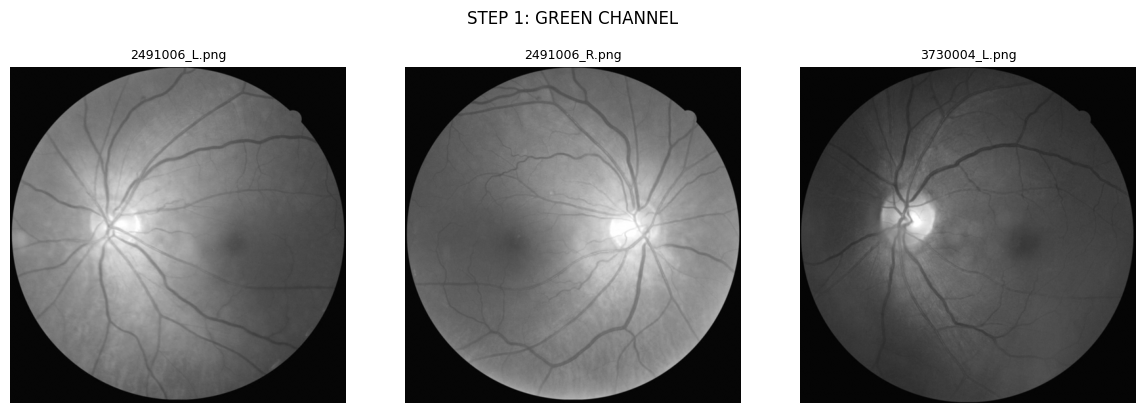

In [4]:
def save_green_one(filename):
    out = GREEN_DIR / filename

    if out.exists():
        return "skipped"

    orig = find_orig_path(filename)
    bgr = cv2.imread(str(orig))

    if bgr is None:
        raise FileNotFoundError(orig)

    green = bgr[:, :, 1]

    out.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out), green)

    return "computed"


ok, skipped, fail = 0, 0, 0

for fn in tqdm(file_list, desc="GREEN"):
    try:
        status = save_green_one(fn)

        if status == "skipped":
            skipped += 1
        else:
            ok += 1

    except Exception as e:
        fail += 1
        print("GREEN failed:", fn, e)

print("GREEN done. computed =", ok, "skipped =", skipped, "fail =", fail)

green_imgs = []
for fn in SAMPLE_FILES:
    g = cv2.imread(str(GREEN_DIR / fn), cv2.IMREAD_GRAYSCALE)
    green_imgs.append(g)

show_three(green_imgs, SAMPLE_FILES, cmap="gray", suptitle="STEP 1: GREEN CHANNEL")

CLAHE: 100%|██████████| 5806/5806 [00:00<00:00, 13838.92it/s]


CLAHE done. computed = 0 skipped = 5806 fail = 0


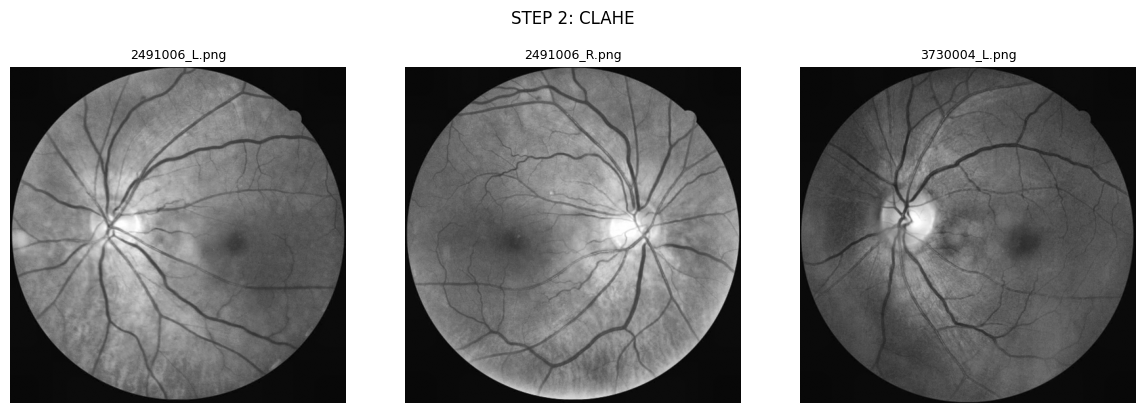

In [5]:
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP,
    tileGridSize=CLAHE_TILE
)

def save_clahe_one(filename):
    out = CLAHE_DIR / filename

    if out.exists():
        return "skipped"

    g_path = GREEN_DIR / filename
    g = cv2.imread(str(g_path), cv2.IMREAD_GRAYSCALE)

    if g is None:
        raise FileNotFoundError(g_path)

    gc = clahe.apply(g)

    out.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(out), gc)

    return "computed"


ok, skipped, fail = 0, 0, 0

for fn in tqdm(file_list, desc="CLAHE"):
    try:
        status = save_clahe_one(fn)

        if status == "skipped":
            skipped += 1
        else:
            ok += 1

    except Exception as e:
        fail += 1
        print("CLAHE failed:", fn, e)

print("CLAHE done. computed =", ok, "skipped =", skipped, "fail =", fail)

clahe_imgs = []
for fn in SAMPLE_FILES:
    x = cv2.imread(str(CLAHE_DIR / fn), cv2.IMREAD_GRAYSCALE)
    clahe_imgs.append(x)

show_three(clahe_imgs, SAMPLE_FILES, cmap="gray", suptitle="STEP 2: CLAHE")

MINMAX: 100%|██████████| 5806/5806 [00:00<00:00, 27393.98it/s]


MINMAX done. computed = 0 skipped = 5806 fail = 0


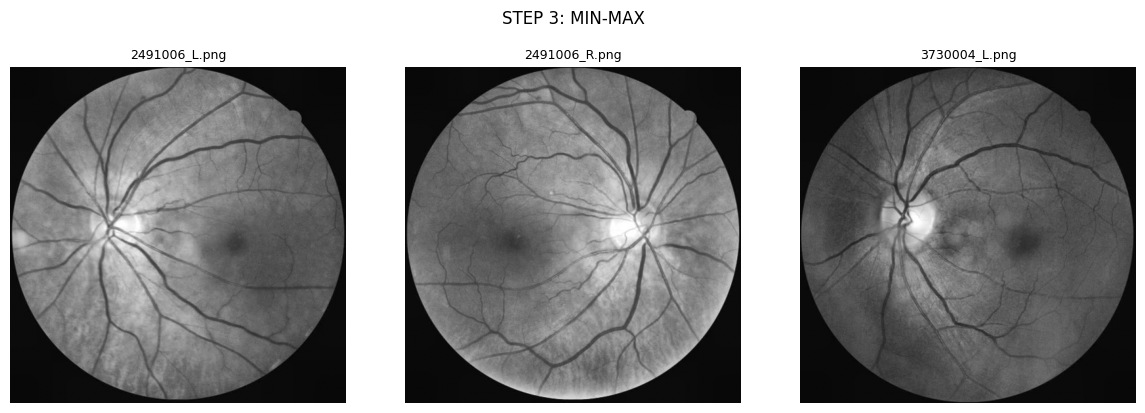

In [7]:
def save_minmax_one(filename):
    base = Path(filename).stem

    npy_path = MINMAX_DIR / f"{base}.npy"
    png_path = MINMAX_DIR / filename

    if npy_path.exists() and png_path.exists():
        return "skipped"

    x_path = CLAHE_DIR / filename
    x = cv2.imread(str(x_path), cv2.IMREAD_GRAYSCALE)

    if x is None:
        raise FileNotFoundError(x_path)

    xf = x.astype(np.float32)
    mn, mx = xf.min(), xf.max()

    if mx > mn:
        x01 = (xf - mn) / (mx - mn)
    else:
        x01 = np.zeros_like(xf, dtype=np.float32)

    np.save(str(npy_path), x01.astype(np.float32))

    x8 = (x01 * 255.0).round().astype(np.uint8)

    png_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(png_path), x8)

    return "computed"


ok, skipped, fail = 0, 0, 0

for fn in tqdm(file_list, desc="MINMAX"):
    try:
        status = save_minmax_one(fn)

        if status == "skipped":
            skipped += 1
        else:
            ok += 1

    except Exception as e:
        fail += 1
        print("MINMAX failed:", fn, e)

print("MINMAX done. computed =", ok, "skipped =", skipped, "fail =", fail)

mm_imgs = []
for fn in SAMPLE_FILES:
    x = cv2.imread(str(MINMAX_DIR / fn), cv2.IMREAD_GRAYSCALE)
    mm_imgs.append(x)

show_three(mm_imgs, SAMPLE_FILES, cmap="gray", suptitle="STEP 3: MIN-MAX")

In [8]:
def dwt2_pyramid(img01, wavelet="db4", level=3):
    levels = []
    current = img01.astype(np.float32)

    for _ in range(level):
        cA, (cH, cV, cD) = pywt.dwt2(current, wavelet=wavelet)
        levels.append((cA, cH, cV, cD))
        current = cA

    return levels


def save_dwt_pyramid_one(filename):
    base = Path(filename).stem
    out_dir = DWT_DIR / base
    chk = out_dir / f"L{LEVEL}_HH.npy"

    if chk.exists():
        return "skipped"

    img_path = MINMAX_DIR / f"{base}.npy"

    if not img_path.exists():
        raise FileNotFoundError(img_path)

    img01 = np.load(str(img_path)).astype(np.float32)
    levels = dwt2_pyramid(img01, wavelet=WAVELET, level=LEVEL)

    out_dir.mkdir(parents=True, exist_ok=True)

    for l, (cA, cH, cV, cD) in enumerate(levels, start=1):
        np.save(str(out_dir / f"L{l}_LL.npy"), cA.astype(np.float32))
        np.save(str(out_dir / f"L{l}_LH.npy"), cH.astype(np.float32))
        np.save(str(out_dir / f"L{l}_HL.npy"), cV.astype(np.float32))
        np.save(str(out_dir / f"L{l}_HH.npy"), cD.astype(np.float32))

    return "computed"


ok, skipped, fail = 0, 0, 0

for fn in tqdm(file_list, desc="DWT(all)"):
    try:
        status = save_dwt_pyramid_one(fn)

        if status == "skipped":
            skipped += 1
        else:
            ok += 1

    except Exception as e:
        fail += 1
        print("DWT failed:", fn, e)

print("DWT done. computed =", ok, "skipped =", skipped, "fail =", fail)

DWT(all): 100%|██████████| 5806/5806 [00:01<00:00, 2942.39it/s]

DWT done. computed = 0 skipped = 5806 fail = 0


In [9]:
out_csv = ENERGY_DIR / f"wavelet_energy_norm_L{LEVEL}.csv"

if out_csv.exists():
    print("Energy features already exist. Loading existing file...")
    df_energy = pd.read_csv(out_csv)
    print("Loaded:", out_csv)
    display(df_energy.head())

else:
    print("Energy file not found. Computing features...")

    def energy_per_coeff(arr: np.ndarray) -> float:
        arr = arr.astype(np.float32)
        return float(np.sum(arr * arr) / (arr.size + 1e-12))

    def compute_energy_features_one(filename: str) -> dict:
        base = Path(filename).stem
        img_dir = DWT_DIR / base

        feats = {"filename": filename}

        for l in range(1, LEVEL + 1):
            for band in ["LL", "LH", "HL", "HH"]:
                sub_path = img_dir / f"L{l}_{band}.npy"

                if not sub_path.exists():
                    raise FileNotFoundError(sub_path)

                sub = np.load(str(sub_path))
                feats[f"L{l}_{band}_E"] = energy_per_coeff(sub)

            feats[f"L{l}_DETAIL_E"] = (
                feats[f"L{l}_LH_E"] +
                feats[f"L{l}_HL_E"] +
                feats[f"L{l}_HH_E"]
            )

        total_detail = sum(feats[f"L{l}_DETAIL_E"] for l in range(1, LEVEL + 1)) + 1e-12
        feats["TOTAL_DETAIL_E"] = total_detail

        for l in range(1, LEVEL + 1):
            feats[f"L{l}_REL_DETAIL"] = feats[f"L{l}_DETAIL_E"] / total_detail

        return feats

    rows = []
    ok, fail = 0, 0

    for fn in tqdm(file_list, desc="ENERGY(norm)"):
        try:
            rows.append(compute_energy_features_one(fn))
            ok += 1

        except Exception as e:
            fail += 1
            print("Energy(norm) failed:", fn, e)

    df_energy = pd.DataFrame(rows)

    meta = df_all.drop_duplicates("filename")[["filename", "label", "group"]]
    df_energy = df_energy.merge(meta, on="filename", how="left")

    df_energy.to_csv(out_csv, index=False)

    print("DONE. ok =", ok, "fail =", fail)
    print("Saved:", out_csv)
    display(df_energy.head())

Energy features already exist. Loading existing file...
Loaded: E:\SPCOM - IISc Bangalore\Wavelet_energy\wavelet_energy_norm_L3.csv


,filename,L1_LL_E,L1_LH_E,L1_HL_E,L1_HH_E,L1_DETAIL_E,L2_LL_E,L2_LH_E,L2_HL_E,L2_HH_E,...,L3_LH_E,L3_HL_E,L3_HH_E,L3_DETAIL_E,TOTAL_DETAIL_E,L1_REL_DETAIL,L2_REL_DETAIL,L3_REL_DETAIL,label,group
0,2491006_L.png,0.761360,0.000197,0.000244,0.000067,0.000508,2.889900,0.002631,0.003495,0.000625,...,0.032112,0.032067,0.009969,0.074148,0.081407,0.006239,0.082932,0.910830,0,1
1,2491006_R.png,0.813980,0.000327,0.000392,0.000090,0.000809,3.083746,0.004408,0.005536,0.001047,...,0.042484,0.043928,0.011567,0.097979,0.109779,0.007368,0.100122,0.892510,0,1
2,3730004_L.png,0.408284,0.000256,0.000224,0.000083,0.000563,1.548597,0.002032,0.002068,0.000577,...,0.018057,0.012961,0.004561,0.035579,0.040820,0.013789,0.114593,0.871618,1,1
3,3730004_R.png,0.367288,0.000254,0.000224,0.000080,0.000558,1.392499,0.002142,0.002069,0.000567,...,0.016952,0.013259,0.004153,0.034364,0.039699,0.014048,0.120345,0.865607,1,1
4,3730006_L.png,1.124495,0.000404,0.000380,0.000106,0.000891,4.263142,0.004233,0.004194,0.001138,...,0.037814,0.037106,0.010320,0.085240,0.095695,0.009306,0.099955,0.890738,1,1


In [10]:
out_csv = BASE_DIR / "wavelet_energy_autocorr_features.csv"

if out_csv.exists():
    print("Autocorrelation features already exist. Loading file...")
    df_all_features = pd.read_csv(out_csv)
    print("Loaded:", out_csv)
    display(df_all_features.head())

else:
    print("Autocorrelation features not found. Computing...")

    def autocorr2d(x):
        x = x.astype(np.float32)

        f = np.fft.fft2(x)
        ac = np.fft.ifft2(f * np.conj(f)).real
        ac = np.fft.fftshift(ac)

        ac = ac / (np.max(np.abs(ac)) + 1e-12)
        return ac.astype(np.float32)

    def autocorr_features(sub, shift_start=5, shift_end=20):
        ac = autocorr2d(sub)

        h, w = ac.shape
        cy, cx = h // 2, w // 2

        mean_corr = float(np.mean(ac))
        std_corr  = float(np.std(ac))

        line = ac[cy, :]

        s1 = min(cx + shift_start, w)
        s2 = min(cx + shift_end, w)

        if s2 > s1:
            decay = float(np.mean(np.abs(line[s1:s2])))
        else:
            decay = 0.0

        return mean_corr, std_corr, decay

    def compute_autocorr_features_one(filename):
        base = Path(filename).stem
        img_dir = DWT_DIR / base

        feats = {"filename": filename}

        for l in range(1, LEVEL + 1):
            for band in BANDS:
                sub_path = img_dir / f"L{l}_{band}.npy"

                if not sub_path.exists():
                    raise FileNotFoundError(sub_path)

                sub = np.load(str(sub_path))

                mean_c, std_c, decay = autocorr_features(sub)

                feats[f"L{l}_{band}_AC_mean"]  = mean_c
                feats[f"L{l}_{band}_AC_std"]   = std_c
                feats[f"L{l}_{band}_AC_decay"] = decay

        return feats

    rows = []
    ok, fail = 0, 0

    for fn in tqdm(file_list, desc="AUTOCORR"):
        try:
            rows.append(compute_autocorr_features_one(fn))
            ok += 1

        except Exception as e:
            fail += 1
            print("AC failed:", fn, e)

    df_ac = pd.DataFrame(rows)

    df_all_features = df_energy.merge(df_ac, on="filename", how="left")
    df_all_features.to_csv(out_csv, index=False)

    print("Autocorrelation features saved:", out_csv)
    print("ok =", ok, "fail =", fail)
    display(df_all_features.head())

Autocorrelation features already exist. Loading file...
Loaded: E:\SPCOM - IISc Bangalore\wavelet_energy_autocorr_features.csv


,filename,L1_LL_E,L1_LH_E,L1_HL_E,L1_HH_E,L1_DETAIL_E,L2_LL_E,L2_LH_E,L2_HL_E,L2_HH_E,...,L2_HH_AC_decay,L3_LH_AC_mean,L3_LH_AC_std,L3_LH_AC_decay,L3_HL_AC_mean,L3_HL_AC_std,L3_HL_AC_decay,L3_HH_AC_mean,L3_HH_AC_std,L3_HH_AC_decay
0,2491006_L.png,0.761360,0.000197,0.000244,0.000067,0.000508,2.889900,0.002631,0.003495,0.000625,...,0.006966,2.756654e-07,0.025481,0.012891,0.000204,0.023455,0.029261,1.172347e-05,0.025479,0.024088
1,2491006_R.png,0.813980,0.000327,0.000392,0.000090,0.000809,3.083746,0.004408,0.005536,0.001047,...,0.004727,6.603967e-05,0.025384,0.024099,0.000195,0.025473,0.064328,3.389893e-07,0.025994,0.015629
2,3730004_L.png,0.408284,0.000256,0.000224,0.000083,0.000563,1.548597,0.002032,0.002068,0.000577,...,0.008014,6.475990e-04,0.023104,0.014941,0.000358,0.023136,0.031769,1.377545e-05,0.023748,0.014976
3,3730004_R.png,0.367288,0.000254,0.000224,0.000080,0.000558,1.392499,0.002142,0.002069,0.000567,...,0.007415,1.062296e-03,0.022975,0.018654,0.000086,0.023860,0.030504,5.404749e-05,0.022745,0.012345
4,3730006_L.png,1.124495,0.000404,0.000380,0.000106,0.000891,4.263142,0.004233,0.004194,0.001138,...,0.009531,3.658082e-04,0.022870,0.020443,0.000004,0.022627,0.033569,3.653804e-06,0.024152,0.014480


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

FORCE_RECOMPUTE = False

if "df_all_features" not in globals():
    AC_FEATURES_CSV = BASE_DIR / "wavelet_energy_autocorr_features.csv"

    if not AC_FEATURES_CSV.exists():
        raise FileNotFoundError(f"Missing autocorr feature CSV: {AC_FEATURES_CSV}")

    df_all_features = pd.read_csv(AC_FEATURES_CSV).drop_duplicates("filename").reset_index(drop=True)

print("Using df_all_features:", df_all_features.shape)

def cache_A_path(filename: str) -> Path:
    base = Path(filename).stem
    out_dir = GRAPH_DIR / base
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"A_L{LEVEL}.npy"


def build_adjacency_from_row(row) -> np.ndarray:
    desc = []

    for l in range(1, LEVEL + 1):
        for band in BANDS:
            d = np.array([
                row[f"L{l}_{band}_AC_mean"],
                row[f"L{l}_{band}_AC_std"],
                row[f"L{l}_{band}_AC_decay"],
            ], dtype=np.float32)

            if not np.all(np.isfinite(d)):
                raise ValueError(f"Non-finite AC descriptor for {row['filename']} at L{l}_{band}")

            desc.append(d)

    X = np.stack(desc, axis=0)
    A = cosine_similarity(X).astype(np.float32)

    A = np.clip(A, 0.0, 1.0)
    A = (A + A.T) * 0.5

    # diagonal removed because normalized Laplacian should not be dominated by self-loops
    np.fill_diagonal(A, 0.0)

    return A


ok, skipped, fail = 0, 0, 0

for _, row in tqdm(df_all_features.iterrows(), total=len(df_all_features), desc="BUILD_A"):
    fn = row["filename"]

    try:
        A_path = cache_A_path(fn)

        if A_path.exists() and not FORCE_RECOMPUTE:
            skipped += 1
            continue

        A = build_adjacency_from_row(row)
        np.save(str(A_path), A)

        ok += 1

    except Exception as e:
        fail += 1
        print("Adjacency failed:", fn, e)

print(f"DONE. computed={ok}, skipped={skipped}, failed={fail}")
print("Adjacency matrices saved under:", GRAPH_DIR)

Using df_all_features: (5806, 49)


BUILD_A: 100%|██████████| 5806/5806 [00:00<00:00, 5881.39it/s]

DONE. computed=0, skipped=5806, failed=0
Adjacency matrices saved under: E:\SPCOM - IISc Bangalore\Wavelet_graph


In [12]:
def paths_for_base(base: str):
    out_dir   = GRAPH_DIR / base
    A_path    = out_dir / f"A_L{LEVEL}.npy"
    L_path    = out_dir / f"L_{NORMTAG}_L{LEVEL}.npy"
    eig_path  = out_dir / f"eig_{NORMTAG}_L{LEVEL}.npy"
    meta_path = out_dir / f"spec_meta_{NORMTAG}_L{LEVEL}.npz"

    return out_dir, A_path, L_path, eig_path, meta_path


def valid_eig(eig_path: Path) -> bool:
    try:
        eig = np.load(eig_path)

        return (
            isinstance(eig, np.ndarray)
            and eig.ndim == 1
            and eig.size == LEVEL * 3
            and np.isfinite(eig).all()
        )

    except Exception:
        return False


def normalized_laplacian_from_A(A: np.ndarray) -> np.ndarray:
    A = A.astype(np.float32)

    A = (A + A.T) * 0.5
    np.fill_diagonal(A, 0.0)

    deg = A.sum(axis=1).astype(np.float32)
    inv_sqrt = 1.0 / np.sqrt(np.maximum(deg, 1e-12))

    D_inv_sqrt = np.diag(inv_sqrt)
    I = np.eye(A.shape[0], dtype=np.float32)

    L = I - (D_inv_sqrt @ A @ D_inv_sqrt)
    L = (L + L.T) * 0.5

    return L.astype(np.float32)


def spectral_stats(eig: np.ndarray):
    eig = np.maximum(eig.astype(np.float32), 0.0)

    lam2 = float(eig[1]) if eig.size >= 2 else float("nan")
    lam3 = float(eig[2]) if eig.size >= 3 else float("nan")
    lam_max = float(eig[-1]) if eig.size >= 1 else float("nan")
    spec_std = float(np.std(eig))

    nz = np.maximum(eig[1:], 1e-12)
    p = nz / np.sum(nz)

    spec_entropy = float(-np.sum(p * np.log(p)))

    m = nz.size
    i1 = max(1, m // 3)
    i2 = max(i1 + 1, (2 * m) // 3)

    low_band  = nz[:i1]
    mid_band  = nz[i1:i2]
    high_band = nz[i2:]

    low_energy  = float(np.sum(low_band))
    mid_energy  = float(np.sum(mid_band))
    high_energy = float(np.sum(high_band))

    total_energy = low_energy + mid_energy + high_energy + 1e-12

    return {
        "lam2": lam2,
        "lam3": lam3,
        "lam_max": lam_max,
        "spec_std": spec_std,
        "spec_entropy": spec_entropy,
        "low_ratio": low_energy / total_energy,
        "mid_ratio": mid_energy / total_energy,
        "high_ratio": high_energy / total_energy,
    }


computed, skipped, failed = 0, 0, 0

for fn in tqdm(file_list, desc=f"GRAPH_SPECTRUM_{NORMTAG.upper()}"):
    base = Path(fn).stem

    try:
        out_dir, A_path, L_path, eig_path, meta_path = paths_for_base(base)

        if not A_path.exists():
            raise FileNotFoundError(f"Missing adjacency matrix {A_path}")

        if eig_path.exists() and meta_path.exists() and valid_eig(eig_path):
            skipped += 1
            continue

        A = np.load(A_path)

        if A.shape != (LEVEL * 3, LEVEL * 3):
            raise ValueError(f"Invalid adjacency shape {A.shape} in {A_path}")

        L = normalized_laplacian_from_A(A)
        eig = np.linalg.eigvalsh(L).astype(np.float32)

        stats = spectral_stats(eig)

        out_dir.mkdir(parents=True, exist_ok=True)

        np.save(L_path, L)
        np.save(eig_path, eig)

        np.savez(
            meta_path,
            **{k: np.float32(v) for k, v in stats.items()}
        )

        computed += 1

    except Exception as e:
        failed += 1
        print("Error:", fn, e)

print(f"\nDONE {NORMTAG}")
print(f"computed = {computed}")
print(f"skipped  = {skipped}")
print(f"failed   = {failed}")

GRAPH_SPECTRUM_NORM: 100%|██████████| 5806/5806 [00:39<00:00, 146.43it/s]


DONE norm
computed = 0
skipped  = 5806
failed   = 0


In [13]:
OUT_CSV_NORM = GRAPH_DIR / f"final_features_{NORMTAG}_L{LEVEL}.csv"

if "df_all_features" not in globals():
    ENERGY_CSV = ENERGY_DIR / f"wavelet_energy_norm_L{LEVEL}.csv"
    AC_CSV     = BASE_DIR / "wavelet_energy_autocorr_features.csv"

    df_energy = pd.read_csv(ENERGY_CSV).drop_duplicates("filename")
    df_ac     = pd.read_csv(AC_CSV).drop_duplicates("filename")

    df_all_features = df_energy.merge(df_ac, on="filename", how="inner")

if OUT_CSV_NORM.exists():
    print("Final normalized feature table already exists. Loading:")
    print(OUT_CSV_NORM)
    df_final_norm = pd.read_csv(OUT_CSV_NORM)

else:
    print("Final normalized feature table not found. Creating...")

    rows = []

    for fn in tqdm(df_all_features["filename"].drop_duplicates().tolist(), desc=f"COLLECT_SPECTRAL_{NORMTAG.upper()}"):
        base = Path(fn).stem
        out_dir = GRAPH_DIR / base

        eig_path  = out_dir / f"eig_{NORMTAG}_L{LEVEL}.npy"
        meta_path = out_dir / f"spec_meta_{NORMTAG}_L{LEVEL}.npz"

        feat = {"filename": fn}

        if eig_path.exists() and meta_path.exists():
            eig = np.load(eig_path).astype(np.float32)

            with np.load(meta_path) as meta:
                feat.update({
                    f"graph_{NORMTAG}_lam2": float(meta["lam2"]),
                    f"graph_{NORMTAG}_lam3": float(meta["lam3"]),
                    f"graph_{NORMTAG}_lam_max": float(meta["lam_max"]),
                    f"graph_{NORMTAG}_spec_std": float(meta["spec_std"]),
                    f"graph_{NORMTAG}_spec_entropy": float(meta["spec_entropy"]),
                    f"graph_{NORMTAG}_low_ratio": float(meta["low_ratio"]),
                    f"graph_{NORMTAG}_mid_ratio": float(meta["mid_ratio"]),
                    f"graph_{NORMTAG}_high_ratio": float(meta["high_ratio"]),
                })

            for i in range(eig.size):
                feat[f"graph_{NORMTAG}_eig_{i}"] = float(eig[i])

        rows.append(feat)

    df_graph_norm = pd.DataFrame(rows)

    df_final_norm = df_all_features.merge(df_graph_norm, on="filename", how="left")

    meta_cols = df_all[["filename", "label", "group"]].drop_duplicates("filename")

    df_final_norm = df_final_norm.drop(columns=["label", "group"], errors="ignore")
    df_final_norm = df_final_norm.merge(meta_cols, on="filename", how="left")

    df_final_norm.to_csv(OUT_CSV_NORM, index=False)

    print("Saved:", OUT_CSV_NORM)

print("df_final_norm shape:", df_final_norm.shape)

graph_cols = [c for c in df_final_norm.columns if c.startswith(f"graph_{NORMTAG}_")]
print("No. of normalized graph columns:", len(graph_cols))
print(graph_cols)

Final normalized feature table already exists. Loading:
E:\SPCOM - IISc Bangalore\Wavelet_graph\final_features_norm_L3.csv
df_final_norm shape: (5806, 68)
No. of normalized graph columns: 17
['graph_norm_lam2', 'graph_norm_lam3', 'graph_norm_lam_max', 'graph_norm_spec_std', 'graph_norm_spec_entropy', 'graph_norm_low_ratio', 'graph_norm_mid_ratio', 'graph_norm_high_ratio', 'graph_norm_eig_0', 'graph_norm_eig_1', 'graph_norm_eig_2', 'graph_norm_eig_3', 'graph_norm_eig_4', 'graph_norm_eig_5', 'graph_norm_eig_6', 'graph_norm_eig_7', 'graph_norm_eig_8']


In [14]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
)

IN_CSV = GRAPH_DIR / f"final_features_{NORMTAG}_L{LEVEL}.csv"
OUT_RES = GRAPH_DIR / f"ablation_results_{NORMTAG}_L{LEVEL}_RF.csv"

ENERGY_CSV = ENERGY_DIR / f"wavelet_energy_norm_L{LEVEL}.csv"
AC_CSV     = BASE_DIR / "wavelet_energy_autocorr_features.csv"

if OUT_RES.exists():
    print("RF ablation result already exists. Loading:")
    print(OUT_RES)
    res_rf = pd.read_csv(OUT_RES)
    display(res_rf)

else:
    print("RF ablation result not found. Running...")

    df = pd.read_csv(IN_CSV)

    if ("label" not in df.columns) or ("group" not in df.columns):
        df_meta = df_all[["filename", "label", "group"]].drop_duplicates("filename")
        df = df.merge(df_meta, on="filename", how="left")

    df_energy_src = pd.read_csv(ENERGY_CSV).drop_duplicates("filename")
    df_ac_src     = pd.read_csv(AC_CSV).drop_duplicates("filename")

    meta_cols = {"filename", "label", "group"}

    energy_cols = [c for c in df_energy_src.columns if c not in meta_cols and c in df.columns]
    ac_cols     = [c for c in df_ac_src.columns if c not in meta_cols and c in df.columns]

    graph_cols_main = [
        "graph_norm_lam2",
        "graph_norm_lam3",
        "graph_norm_lam_max",
        "graph_norm_spec_std",
        "graph_norm_spec_entropy",
        "graph_norm_low_ratio",
        "graph_norm_mid_ratio",
        "graph_norm_high_ratio",
    ]

    graph_cols_main = [c for c in graph_cols_main if c in df.columns]

    print("sklearn version:", sklearn.__version__)
    print("n energy cols:", len(energy_cols))
    print("n ac cols    :", len(ac_cols))
    print("n graph cols :", len(graph_cols_main))

    settings = {
        "Energy only": energy_cols,
        "Energy + Autocorr": energy_cols + ac_cols,
        "Energy + Autocorr + GraphSpectrum": energy_cols + ac_cols + graph_cols_main,
    }

    train_df = df[df["group"] == 1].copy()
    val_df   = df[df["group"] == 2].copy()
    test_df  = df[df["group"] == 3].copy()

    print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
    print("Val  :", val_df.shape, val_df["label"].value_counts().to_dict())
    print("Test :", test_df.shape, test_df["label"].value_counts().to_dict())

    results = []

    for setting_name, feat_cols in settings.items():
        feat_cols = [c for c in feat_cols if c in df.columns]
        feat_cols = list(dict.fromkeys(feat_cols))

        print(f"{setting_name}: {len(feat_cols)} features")

        X_train = train_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_train = train_df["label"].to_numpy()

        X_val = val_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_val = val_df["label"].to_numpy()

        X_test = test_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_test = test_df["label"].to_numpy()

        clf = RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        clf.fit(X_train, y_train)

        val_prob = clf.predict_proba(X_val)[:, 1]
        test_prob = clf.predict_proba(X_test)[:, 1]

        val_pred = (val_prob >= 0.5).astype(int)
        test_pred = (test_prob >= 0.5).astype(int)

        row = {
            "model": "RF",
            "setting": setting_name,
            "n_features": len(feat_cols),
            "n_train": len(train_df),
            "n_val": len(val_df),
            "n_test": len(test_df),

            "rf_n_estimators": 300,
            "rf_max_depth": 8,
            "rf_min_samples_leaf": 5,
            "rf_class_weight": "balanced",
            "rf_random_state": 42,
            "sklearn_version": sklearn.__version__,

            "val_acc": accuracy_score(y_val, val_pred),
            "val_prec": precision_score(y_val, val_pred, zero_division=0),
            "val_rec": recall_score(y_val, val_pred, zero_division=0),
            "val_f1": f1_score(y_val, val_pred, zero_division=0),
            "val_auc": roc_auc_score(y_val, val_prob),
            "val_mcc": matthews_corrcoef(y_val, val_pred),

            "test_acc": accuracy_score(y_test, test_pred),
            "test_prec": precision_score(y_test, test_pred, zero_division=0),
            "test_rec": recall_score(y_test, test_pred, zero_division=0),
            "test_f1": f1_score(y_test, test_pred, zero_division=0),
            "test_auc": roc_auc_score(y_test, test_prob),
            "test_mcc": matthews_corrcoef(y_test, test_pred),
        }

        results.append(row)

    res_rf = pd.DataFrame(results)
    res_rf.to_csv(OUT_RES, index=False)

    print(res_rf)
    print("Saved:", OUT_RES)

RF ablation result already exists. Loading:
E:\SPCOM - IISc Bangalore\Wavelet_graph\ablation_results_norm_L3_RF.csv


,model,setting,n_features,n_train,n_val,n_test,val_acc,val_prec,val_rec,val_f1,val_auc,val_mcc,test_acc,test_prec,test_rec,test_f1,test_auc,test_mcc
0,RF,Energy only,19,5206,400,200,0.6300,0.603175,0.760,0.672566,0.694475,0.269260,0.650,0.620968,0.77,0.687500,0.7272,0.309032
1,RF,Energy + Autocorr,46,5206,400,200,0.6325,0.592982,0.845,0.696907,0.724050,0.292755,0.720,0.671875,0.86,0.754386,0.7980,0.458333
2,RF,Energy + Autocorr + GraphSpectrum,54,5206,400,200,0.6275,0.584718,0.880,0.702595,0.735000,0.295440,0.735,0.676692,0.90,0.772532,0.8007,0.497891


In [15]:
IN_CSV = GRAPH_DIR / f"final_features_{NORMTAG}_L{LEVEL}.csv"
OUT_RES_SVM = GRAPH_DIR / f"ablation_results_{NORMTAG}_L{LEVEL}_SVM_RBF.csv"

ENERGY_CSV = ENERGY_DIR / f"wavelet_energy_norm_L{LEVEL}.csv"
AC_CSV     = BASE_DIR / "wavelet_energy_autocorr_features.csv"

if OUT_RES_SVM.exists():
    print("SVM-RBF ablation result already exists. Loading:")
    print(OUT_RES_SVM)
    res_svm = pd.read_csv(OUT_RES_SVM)
    display(res_svm)

else:
    print("SVM-RBF ablation result not found. Running...")

    df = pd.read_csv(IN_CSV)

    if ("label" not in df.columns) or ("group" not in df.columns):
        df_meta = df_all[["filename", "label", "group"]].drop_duplicates("filename")
        df = df.merge(df_meta, on="filename", how="left")

    df_energy_src = pd.read_csv(ENERGY_CSV).drop_duplicates("filename")
    df_ac_src     = pd.read_csv(AC_CSV).drop_duplicates("filename")

    meta_cols = {"filename", "label", "group"}

    energy_cols = [c for c in df_energy_src.columns if c not in meta_cols and c in df.columns]
    ac_cols     = [c for c in df_ac_src.columns if c not in meta_cols and c in df.columns]

    graph_cols_main = [
        "graph_norm_lam2",
        "graph_norm_lam3",
        "graph_norm_lam_max",
        "graph_norm_spec_std",
        "graph_norm_spec_entropy",
        "graph_norm_low_ratio",
        "graph_norm_mid_ratio",
        "graph_norm_high_ratio",
    ]
    graph_cols_main = [c for c in graph_cols_main if c in df.columns]

    print("sklearn version:", sklearn.__version__)
    print("n energy cols:", len(energy_cols))
    print("n ac cols    :", len(ac_cols))
    print("n graph cols :", len(graph_cols_main))

    settings = {
        "Energy only": energy_cols,
        "Energy + Autocorr": energy_cols + ac_cols,
        "Energy + Autocorr + GraphSpectrum": energy_cols + ac_cols + graph_cols_main,
    }

    train_df = df[df["group"] == 1].copy()
    val_df   = df[df["group"] == 2].copy()
    test_df  = df[df["group"] == 3].copy()

    print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
    print("Val  :", val_df.shape, val_df["label"].value_counts().to_dict())
    print("Test :", test_df.shape, test_df["label"].value_counts().to_dict())

    results = []

    for setting_name, feat_cols in settings.items():
        feat_cols = [c for c in feat_cols if c in df.columns]
        feat_cols = list(dict.fromkeys(feat_cols))

        print(f"{setting_name}: {len(feat_cols)} features")

        X_train = train_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_train = train_df["label"].to_numpy()

        X_val = val_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_val = val_df["label"].to_numpy()

        X_test = test_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_test = test_df["label"].to_numpy()

        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight="balanced",
                probability=True,
                random_state=42,
            ))
        ])

        clf.fit(X_train, y_train)

        val_prob  = clf.predict_proba(X_val)[:, 1]
        test_prob = clf.predict_proba(X_test)[:, 1]

        val_pred  = (val_prob >= 0.5).astype(int)
        test_pred = (test_prob >= 0.5).astype(int)

        row = {
            "model": "SVM-RBF",
            "setting": setting_name,
            "n_features": len(feat_cols),
            "n_train": len(train_df),
            "n_val": len(val_df),
            "n_test": len(test_df),

            "svm_kernel": "rbf",
            "svm_C": 1.0,
            "svm_gamma": "scale",
            "svm_class_weight": "balanced",
            "svm_probability": True,
            "svm_random_state": 42,
            "sklearn_version": sklearn.__version__,

            "val_acc": accuracy_score(y_val, val_pred),
            "val_prec": precision_score(y_val, val_pred, zero_division=0),
            "val_rec": recall_score(y_val, val_pred, zero_division=0),
            "val_f1": f1_score(y_val, val_pred, zero_division=0),
            "val_auc": roc_auc_score(y_val, val_prob),
            "val_mcc": matthews_corrcoef(y_val, val_pred),

            "test_acc": accuracy_score(y_test, test_pred),
            "test_prec": precision_score(y_test, test_pred, zero_division=0),
            "test_rec": recall_score(y_test, test_pred, zero_division=0),
            "test_f1": f1_score(y_test, test_pred, zero_division=0),
            "test_auc": roc_auc_score(y_test, test_prob),
            "test_mcc": matthews_corrcoef(y_test, test_pred),
        }

        results.append(row)

    res_svm = pd.DataFrame(results)
    res_svm.to_csv(OUT_RES_SVM, index=False)

    display(res_svm)
    print("Saved:", OUT_RES_SVM)

SVM-RBF ablation result already exists. Loading:
E:\SPCOM - IISc Bangalore\Wavelet_graph\ablation_results_norm_L3_SVM_RBF.csv


,model,setting,n_features,n_train,n_val,n_test,val_acc,val_f1,val_auc,test_acc,test_f1,test_auc
0,SVM_RBF,Energy only,19,5206,400,200,0.5450,0.681818,0.701525,0.550,0.678571,0.7771
1,SVM_RBF,Energy + Autocorr,46,5206,400,200,0.5275,0.674699,0.679450,0.545,0.680702,0.7405
2,SVM_RBF,Energy + Autocorr + GraphSpectrum,54,5206,400,200,0.5375,0.679376,0.676550,0.560,0.690141,0.7410


In [16]:
IN_CSV = GRAPH_DIR / f"final_features_{NORMTAG}_L{LEVEL}.csv"
OUT_RES_XGB = GRAPH_DIR / f"ablation_results_{NORMTAG}_L{LEVEL}_XGB.csv"

ENERGY_CSV = ENERGY_DIR / f"wavelet_energy_norm_L{LEVEL}.csv"
AC_CSV     = BASE_DIR / "wavelet_energy_autocorr_features.csv"

if OUT_RES_XGB.exists():
    print("XGBoost ablation result already exists. Loading:")
    print(OUT_RES_XGB)
    res_xgb = pd.read_csv(OUT_RES_XGB)
    display(res_xgb)

else:
    print("XGBoost ablation result not found. Running...")

    df = pd.read_csv(IN_CSV)

    if ("label" not in df.columns) or ("group" not in df.columns):
        df_meta = df_all[["filename", "label", "group"]].drop_duplicates("filename")
        df = df.merge(df_meta, on="filename", how="left")

    df_energy_src = pd.read_csv(ENERGY_CSV).drop_duplicates("filename")
    df_ac_src     = pd.read_csv(AC_CSV).drop_duplicates("filename")

    meta_cols = {"filename", "label", "group"}

    energy_cols = [c for c in df_energy_src.columns if c not in meta_cols and c in df.columns]
    ac_cols     = [c for c in df_ac_src.columns if c not in meta_cols and c in df.columns]

    graph_cols_main = [
        "graph_norm_lam2",
        "graph_norm_lam3",
        "graph_norm_lam_max",
        "graph_norm_spec_std",
        "graph_norm_spec_entropy",
        "graph_norm_low_ratio",
        "graph_norm_mid_ratio",
        "graph_norm_high_ratio",
    ]
    graph_cols_main = [c for c in graph_cols_main if c in df.columns]

    print("n energy cols:", len(energy_cols))
    print("n ac cols    :", len(ac_cols))
    print("n graph cols :", len(graph_cols_main))

    settings = {
        "Energy only": energy_cols,
        "Energy + Autocorr": energy_cols + ac_cols,
        "Energy + Autocorr + GraphSpectrum": energy_cols + ac_cols + graph_cols_main,
    }

    train_df = df[df["group"] == 1].copy()
    val_df   = df[df["group"] == 2].copy()
    test_df  = df[df["group"] == 3].copy()

    print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
    print("Val  :", val_df.shape, val_df["label"].value_counts().to_dict())
    print("Test :", test_df.shape, test_df["label"].value_counts().to_dict())

    # imbalance handling for XGBoost
    n_neg = int((train_df["label"] == 0).sum())
    n_pos = int((train_df["label"] == 1).sum())
    scale_pos_weight = n_neg / max(n_pos, 1)

    print("scale_pos_weight:", scale_pos_weight)

    results = []

    for setting_name, feat_cols in settings.items():
        feat_cols = [c for c in feat_cols if c in df.columns]
        feat_cols = list(dict.fromkeys(feat_cols))

        print(f"{setting_name}: {len(feat_cols)} features")

        X_train = train_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_train = train_df["label"].to_numpy()

        X_val = val_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_val = val_df["label"].to_numpy()

        X_test = test_df[feat_cols].fillna(0.0).to_numpy(dtype=np.float32)
        y_test = test_df["label"].to_numpy()

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
        )

        clf.fit(X_train, y_train)

        val_prob  = clf.predict_proba(X_val)[:, 1]
        test_prob = clf.predict_proba(X_test)[:, 1]

        val_pred  = (val_prob >= 0.5).astype(int)
        test_pred = (test_prob >= 0.5).astype(int)

        row = {
            "model": "XGBoost",
            "setting": setting_name,
            "n_features": len(feat_cols),
            "n_train": len(train_df),
            "n_val": len(val_df),
            "n_test": len(test_df),

            "xgb_n_estimators": 300,
            "xgb_max_depth": 4,
            "xgb_learning_rate": 0.05,
            "xgb_subsample": 0.8,
            "xgb_colsample_bytree": 0.8,
            "xgb_scale_pos_weight": scale_pos_weight,
            "xgb_random_state": 42,

            "val_acc": accuracy_score(y_val, val_pred),
            "val_prec": precision_score(y_val, val_pred, zero_division=0),
            "val_rec": recall_score(y_val, val_pred, zero_division=0),
            "val_f1": f1_score(y_val, val_pred, zero_division=0),
            "val_auc": roc_auc_score(y_val, val_prob),
            "val_mcc": matthews_corrcoef(y_val, val_pred),

            "test_acc": accuracy_score(y_test, test_pred),
            "test_prec": precision_score(y_test, test_pred, zero_division=0),
            "test_rec": recall_score(y_test, test_pred, zero_division=0),
            "test_f1": f1_score(y_test, test_pred, zero_division=0),
            "test_auc": roc_auc_score(y_test, test_prob),
            "test_mcc": matthews_corrcoef(y_test, test_pred),
        }

        results.append(row)

    res_xgb = pd.DataFrame(results)
    res_xgb.to_csv(OUT_RES_XGB, index=False)

    display(res_xgb)
    print("Saved:", OUT_RES_XGB)

XGBoost ablation result already exists. Loading:
E:\SPCOM - IISc Bangalore\Wavelet_graph\ablation_results_norm_L3_XGB.csv


,model,setting,n_features,n_train,n_val,n_test,val_acc,val_f1,val_auc,test_acc,test_f1,test_auc
0,XGB,Energy only,19,5206,400,200,0.6250,0.684874,0.677775,0.65,0.687500,0.7351
1,XGB,Energy + Autocorr,46,5206,400,200,0.6400,0.694915,0.712275,0.70,0.732143,0.7915
2,XGB,Energy + Autocorr + GraphSpectrum,54,5206,400,200,0.6325,0.690526,0.720025,0.70,0.743590,0.7890
